
No matching FPI Moments file for timestamp 2024-03-01 23:22:33
No matching FPI Moments file for timestamp 2024-03-01 23:29:13

Selected First Matched File Set:
  FPI Distribution File: mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf
  FGM File: mms1_fgm_brst_l2_20240301230743_v5.441.0.cdf
  FPI Moments File: mms1_fpi_brst_l2_des-moms_20240301230743_v3.4.0.cdf

Loaded FGM data.
Loaded FPI Distribution data.
Loaded FPI Moments data.
Transposed Distribution Data Shape: (4333, 16, 32, 32)
Reshaped Data Shape: (4333, 16, 32, 32, 1)

Training samples: 1000, Validation samples: 200, Test samples: 200


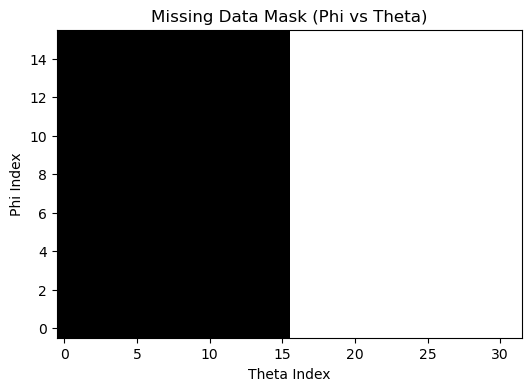

Mask applied to validation set.

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 16, 32, 32, 1)]   0         
                                                                 
 conv3d (Conv3D)             (None, 16, 32, 32, 32)    896       
                                                                 
 max_pooling3d (MaxPooling3  (None, 8, 16, 16, 32)     0         
 D)                                                              
                                                                 
 conv3d_1 (Conv3D)           (None, 8, 16, 16, 64)     55360     
                                                                 
 max_pooling3d_1 (MaxPoolin  (None, 4, 8, 8, 64)       0         
 g3D)                                                            
                                                                 
 conv3d_2 (Conv3D)          

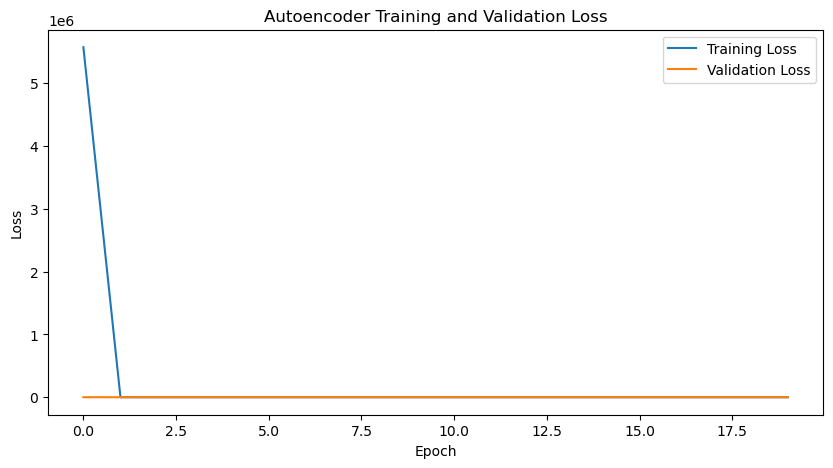

7/7 [==============================] - 1s 70ms/step


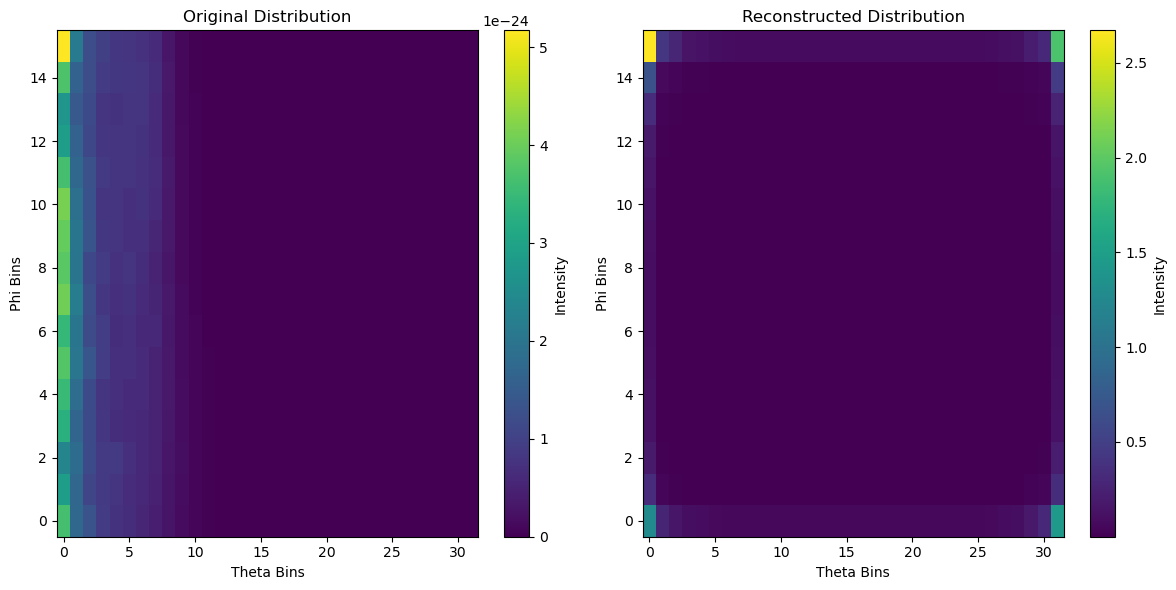


Evaluation and visualization completed.


In [1]:
import os
import datetime
import numpy as np
import cdflib
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping

# Import your existing Skymap class and related functions
# Ensure that the 'skymaps' module is in your Python path
from skymaps.skymap import Skymap, plotMomentsTimeSeries

# ----------------------------------
# 1. Define Paths and Helper Functions
# ----------------------------------

# Paths to the data folders
fpi_dist_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-dist//2024//03//01"
fgm_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fgm"
fpi_moms_folder = "C://Users//ryane//Desktop//Aurora_Project//MMS-FPI-Data-Gaps//data//mms1//fpi//brst//l2//des-moms//2024//03//01"

# Helper function to extract timestamp from filename
def extract_timestamp(filename):
    """
    Extract timestamp from filename.
    Assumes the timestamp is a 14-digit number (YYYYMMDDHHMMSS) part of the filename.

    Example filename: 'mms1_fpi_brst_l2_des-dist_20240301230743_v3.4.0.cdf'
    """
    try:
        parts = filename.split('_')
        for part in parts:
            if part.isdigit() and len(part) == 14:
                return datetime.datetime.strptime(part, "%Y%m%d%H%M%S")
        raise ValueError("No valid timestamp found in filename")
    except Exception as e:
        print(f"Error extracting timestamp from filename: {filename} - {e}")
        return None

# Function to load FGM data
def load_fgm_data(filepath):
    """Load magnetic field data from FGM CDF file."""
    with cdflib.CDF(filepath) as fgm_cdf:
        epoch = fgm_cdf.varget('Epoch')  # Time variable for FGM data
        b_gse = fgm_cdf.varget('mms1_fgm_b_gse_brst_l2')  # Magnetic field in GSE coordinates
    return epoch, b_gse

# Function to load FPI distribution data
def load_fpi_dist_data(filepath):
    """Load distribution data from FPI (`des-dist`) CDF file."""
    with cdflib.CDF(filepath) as fpi_cdf:
        epoch = fpi_cdf.varget('Epoch')  # Time variable for FPI distribution data
        dist_data = fpi_cdf.varget('mms1_des_dist_brst')  # Distribution function data
        theta = fpi_cdf.varget('mms1_des_theta_brst')  # Theta angles
        phi = fpi_cdf.varget('mms1_des_phi_brst')  # Phi angles
    return epoch, dist_data, theta, phi

# Function to load FPI moments data
def load_fpi_moms_data(filepath):
    """Load bulk velocity data from FPI (`des-moms`) CDF file."""
    with cdflib.CDF(filepath) as moms_cdf:
        epoch = moms_cdf.varget('Epoch')  # Time variable for FPI moments data
        bulk_velocity = moms_cdf.varget('mms1_des_bulkv_gse_brst')  # Bulk velocity in GSE coordinates
    return epoch, bulk_velocity

# Function to interpolate magnetic field data to match FPI timestamps
def interpolate_b_field(fgm_epoch, b_gse, fpi_epoch):
    """Interpolate magnetic field data to match FPI timestamps."""
    # Extract only the first three components (x, y, z) from b_gse to match bulk velocity shape
    b_gse = b_gse[:, :3]
    interpolator = interp1d(fgm_epoch, b_gse, axis=0, bounds_error=False, fill_value="extrapolate")
    return interpolator(fpi_epoch)

# ----------------------------------
# 2. Match and Select the First Matched File Set
# ----------------------------------

def match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder):
    """
    Match distribution, magnetic field, and moments CDF files based on their timestamps.

    Returns:
    - matched_files (list of tuples): Each tuple contains (timestamp, fpi_dist_file, fgm_file, fpi_moms_file)
    """
    matched_files = []
    fpi_dist_files = [f for f in os.listdir(fpi_dist_folder) if f.endswith('.cdf')]

    for fpi_dist_filename in fpi_dist_files:
        fpi_dist_timestamp = extract_timestamp(fpi_dist_filename)
        if fpi_dist_timestamp is None:
            continue

        # Find matching FGM file
        fgm_files = [f for f in os.listdir(fgm_folder) if f.endswith('.cdf')]
        matching_fgm = [f for f in fgm_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_fgm:
            print(f"No matching FGM file for timestamp {fpi_dist_timestamp}")
            continue
        fgm_filename = matching_fgm[0]

        # Find matching FPI Moments file
        fpi_moms_files = [f for f in os.listdir(fpi_moms_folder) if f.endswith('.cdf')]
        matching_moms = [f for f in fpi_moms_files if extract_timestamp(f) == fpi_dist_timestamp]
        if not matching_moms:
            print(f"No matching FPI Moments file for timestamp {fpi_dist_timestamp}")
            continue
        fpi_moms_filename = matching_moms[0]

        matched_files.append((fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename))

    return matched_files

# Perform file matching
matched_files = match_files(fpi_dist_folder, fgm_folder, fpi_moms_folder)

# Check if any matched files exist
if not matched_files:
    raise FileNotFoundError("No matched file sets found.")

# Select the first matched set for processing
first_match = matched_files[0]
fpi_dist_timestamp, fpi_dist_filename, fgm_filename, fpi_moms_filename = first_match

print("\nSelected First Matched File Set:")
print(f"  FPI Distribution File: {fpi_dist_filename}")
print(f"  FGM File: {fgm_filename}")
print(f"  FPI Moments File: {fpi_moms_filename}")

# Paths to the matched files
fpi_dist_filepath = os.path.join(fpi_dist_folder, fpi_dist_filename)
fgm_filepath = os.path.join(fgm_folder, fgm_filename)
fpi_moms_filepath = os.path.join(fpi_moms_folder, fpi_moms_filename)

# ----------------------------------
# 3. Load Data from Matched Files
# ----------------------------------

# Load FGM data
fgm_epoch, b_gse = load_fgm_data(fgm_filepath)
print("\nLoaded FGM data.")

# Load FPI Distribution data
fpi_epoch, dist_data, theta, phi = load_fpi_dist_data(fpi_dist_filepath)
print("Loaded FPI Distribution data.")

# Load FPI Moments data
moms_epoch, bulk_velocity = load_fpi_moms_data(fpi_moms_filepath)
print("Loaded FPI Moments data.")

# ----------------------------------
# 4. Preprocess Data
# ----------------------------------

# Transpose distribution data to (time_steps, phi_bins, theta_bins, energy_levels)
# Original shape: (time_steps, energy_levels, phi_bins, theta_bins)
dist_data_transposed = dist_data.transpose(0, 2, 3, 1)  # Shape: (time_steps, phi_bins, theta_bins, energy_levels)

print(f"Transposed Distribution Data Shape: {dist_data_transposed.shape}")  # Example: (4333, 16, 32, 32)

# Reshape data to include channel dimension for Conv3D
X_data = dist_data_transposed.reshape(-1, dist_data_transposed.shape[1], dist_data_transposed.shape[2], dist_data_transposed.shape[3], 1).astype('float32')

print(f"Reshaped Data Shape: {X_data.shape}")  # Example: (4333, 16, 32, 32, 1)

# ----------------------------------
# 5. Split Data into Training, Validation, and Test Sets
# ----------------------------------

# Define split sizes
n_train = 1000  # Adjust based on data size
k_val = 200
k_test = 200

if n_train + k_val + k_test > X_data.shape[0]:
    raise ValueError("Not enough data in the file for specified split sizes.")

X_train = X_data[:n_train]
X_val = X_data[n_train:n_train + k_val]
X_test = X_data[n_train + k_val:n_train + k_val + k_test]

print(f"\nTraining samples: {X_train.shape[0]}, Validation samples: {X_val.shape[0]}, Test samples: {X_test.shape[0]}")

# ----------------------------------
# 6. Apply Mask to the Validation Set
# ----------------------------------

# Define dimensions based on your data shape
phi_bins = X_data.shape[1]  # 16
theta_bins = X_data.shape[2]  # 32
energy_levels = X_data.shape[3]  # 32

# Create a 2D mask for phi_bins x theta_bins
# Mask the right half: theta_bins >= theta_bins // 2
mask_2d = np.zeros((phi_bins, theta_bins), dtype=bool)
mask_2d[:, theta_bins//2:] = True  # Masking the right half

# Visualize the mask for one energy level (optional)
plt.figure(figsize=(6, 4))
plt.imshow(mask_2d, aspect='auto', origin='lower', cmap='gray')
plt.title('Missing Data Mask (Phi vs Theta)')
plt.xlabel('Theta Index')
plt.ylabel('Phi Index')
plt.show()

# Expand mask dimensions to match X_val shape
# X_val shape: (k_val, phi_bins=16, theta_bins=32, energy_levels=32, 1)
mask_expanded = np.expand_dims(mask_2d, axis=(0, 3, 4))  # Shape: (1, 16, 32, 1, 1)
mask_broadcast = np.tile(mask_expanded, (X_val.shape[0], 1, 1, X_val.shape[3], 1))  # Shape: (200, 16, 32, 32, 1)

# Set masked regions to 0.0
X_val_masked = X_val.copy()
X_val_masked[mask_broadcast] = 0.0

print("Mask applied to validation set.")

# ----------------------------------
# 7. Define the Autoencoder Model
# ----------------------------------

def build_autoencoder(input_shape):
    """
    Build and compile the autoencoder model.

    Parameters:
    - input_shape (tuple): Shape of the input data (phi_bins, theta_bins, energy_levels, channels).

    Returns:
    - autoencoder (Model): Compiled Keras model.
    """
    # Encoder
    input_img = Input(shape=input_shape)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling3D((2, 2, 2), padding='same')(x)
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling3D((2, 2, 2), padding='same')(x)
    
    # Decoder
    x = Conv3D(64, (3, 3, 3), activation='relu', padding='same')(encoded)
    x = UpSampling3D((2, 2, 2))(x)
    x = Conv3D(32, (3, 3, 3), activation='relu', padding='same')(x)
    x = UpSampling3D((2, 2, 2))(x)
    decoded = Conv3D(1, (3, 3, 3), activation='sigmoid', padding='same')(x)
    
    # Autoencoder model
    autoencoder = Model(inputs=input_img, outputs=decoded)
    return autoencoder

# Define input shape based on data dimensions
input_shape = (phi_bins, theta_bins, energy_levels, 1)  # (16, 32, 32, 1)

# Build the autoencoder
autoencoder = build_autoencoder(input_shape)
autoencoder.summary()

# ----------------------------------
# 8. Define Custom Loss Functions
# ----------------------------------

# Reshape X_train to (time_steps, phi_bins, theta_bins, energy_levels)
X_train_reshaped = X_train.reshape(-1, phi_bins, theta_bins, energy_levels)  # Shape: (1000, 16, 32, 32)

# **Important:** Ensure that the Skymap class expects data in (theta_bins, phi_bins), not (phi_bins, theta_bins)
# Thus, transpose the data to (time_steps, theta_bins, phi_bins, energy_levels)
X_train_transposed = X_train_reshaped.transpose(0, 2, 1, 3)  # Shape: (1000, 32, 16, 32)

# Initialize Skymap and calculate moments
skymap_train = Skymap(steps=X_train_transposed.shape[0], name="Train_Skymap", nen=energy_levels)
skymap_train.skymap = X_train_transposed
moments_train = skymap_train.momsTS  # Calculate moments

# Extract density moment
actual_density = moments_train.density  # Shape: (time_steps,)

# Convert actual_density to a tensor for use in the custom loss function
actual_density_tensor = tf.convert_to_tensor(actual_density, dtype=tf.float32)

def calculate_density(cube):
    """
    Calculate the 'density' moment of the cube by summing over spatial dimensions.

    Parameters:
    - cube (Tensor): 5D tensor with shape (batch, phi_bins, theta_bins, energy_levels, channels).

    Returns:
    - density: Summed 'density' moment.
    """
    return K.sum(cube, axis=(1, 2, 3))  # Sum over phi, theta, and energy dimensions

def density_loss(y_true, y_pred):
    """
    Custom loss function based on the difference in densities between actual and predicted cubes.

    Parameters:
    - y_true (Tensor): Actual cube.
    - y_pred (Tensor): Predicted cube.
    """
    predicted_density = calculate_density(y_pred)
    return K.mean(K.square(actual_density_tensor - predicted_density))  # Mean squared difference of densities

def combined_loss(y_true, y_pred):
    """
    Custom loss that combines MSE and density-based loss.
    Calculates the mean of MSE and density loss.

    Parameters:
    - y_true (Tensor): Actual cube.
    - y_pred (Tensor): Predicted cube.
    """
    # Calculate MSE
    mse = tf.keras.losses.mean_squared_error(y_true, y_pred)
    
    # Calculate density loss
    density = density_loss(y_true, y_pred)
    
    # Combine the two losses
    return K.mean(mse + density) / 2.0

# ----------------------------------
# 9. Compile the Autoencoder Model
# ----------------------------------

autoencoder.compile(optimizer='adam', loss=combined_loss)
print("\nAutoencoder compiled with combined loss.")

# ----------------------------------
# 10. Train the Autoencoder Model
# ----------------------------------

# Set up early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss for stopping
    patience=10,               # Number of epochs with no improvement after which to stop
    restore_best_weights=True  # Restore the best weights after stopping
)

# Define training parameters
epochs = 1000  # Adjust as needed
batch_size = 32

# Train the autoencoder
history = autoencoder.fit(
    X_train, X_train,
    epochs=epochs,
    batch_size=batch_size,
    shuffle=False,  # Maintain sequential order
    validation_data=(X_val_masked, X_val),
    callbacks=[early_stopping]  # Apply early stopping
)

print("\nModel training completed.")

# ----------------------------------
# 11. Visualize Training Progress
# ----------------------------------

# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ----------------------------------
# 12. Evaluate and Visualize Model Performance
# ----------------------------------

# Make predictions on the test set
X_test_pred = autoencoder.predict(X_test)

# Visualize original vs. reconstructed data for a sample
sample_index = 0  # Change as needed
plt.figure(figsize=(12, 6))

# Original
plt.subplot(1, 2, 1)
# Sum over energy levels to visualize distribution
original_distribution = np.sum(X_test[sample_index, :, :, :, 0], axis=2)  # Shape: (phi_bins=16, theta_bins=32)
plt.imshow(original_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Original Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

# Reconstructed
plt.subplot(1, 2, 2)
reconstructed_distribution = np.sum(X_test_pred[sample_index, :, :, :, 0], axis=2)  # Shape: (phi_bins=16, theta_bins=32)
plt.imshow(reconstructed_distribution, aspect='auto', origin='lower', cmap='viridis')
plt.title('Reconstructed Distribution')
plt.xlabel('Theta Bins')
plt.ylabel('Phi Bins')
plt.colorbar(label='Intensity')

plt.tight_layout()
plt.show()

print("\nEvaluation and visualization completed.")
